In [49]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('C:/Users/egory/Downloads/bmw.csv')

In [21]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [27]:
df.shape

(10781, 9)

<Axes: ylabel='Frequency'>

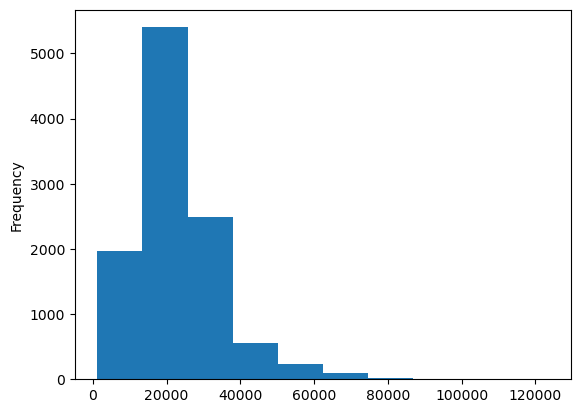

In [23]:
df['price'].plot(kind='hist')

Распределение цен не является нормальным, видим правостороннюю асимметрию. Подавляющее большинство автомобилей сконцентрировано в самом низком ценовом диапазоне (примерно от 0 до 10 000-20 000). Это означает, что основная масса предложений на рынке — это автомобили с невысокой ценой. 

<Axes: ylabel='Frequency'>

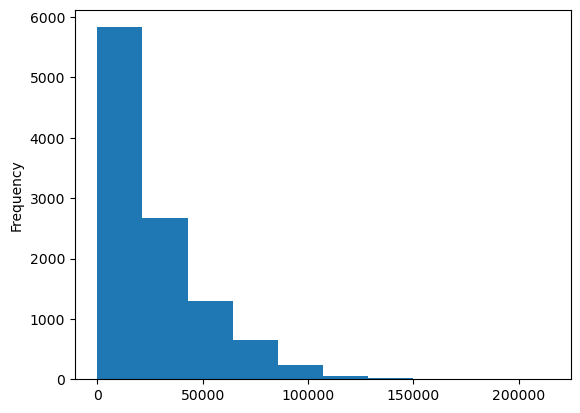

In [30]:
df['mileage'].plot(kind='hist')

Здесь мы тоже видим скос вправо. Количество авто уменьшается с ростом пробега.

<Axes: ylabel='Frequency'>

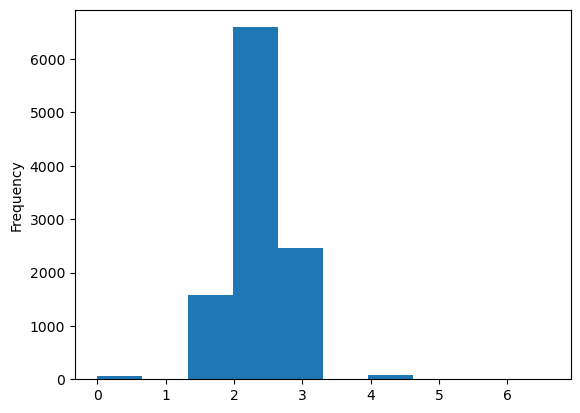

In [35]:
df['engineSize'].plot(kind='hist')

Больше всего автомобилей с объёмом двигателя от 1.3 до 3.2 литра. Экстремальных значений (от 0 до 0.7 и от 4 до 4.6) крайне немного.

In [41]:
df_pivot = df.pivot(columns='model', values='price')

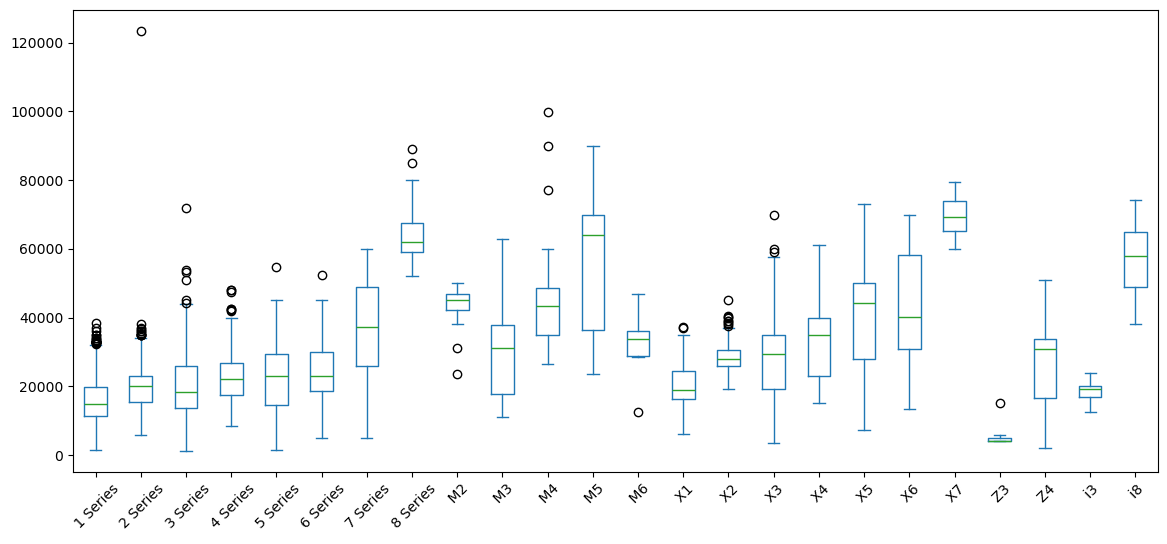

In [55]:
df_pivot.plot(kind='box', figsize=(14,6))
plt.xticks(rotation=45)   
plt.show()

На визуализации видно, что медианная цена существенно различается между моделями BMW. Самые высокие медианные цены наблюдаются у моделей M5, X7, 8 Series и i8, что отражает их принадлежность к премиальному и спортивному сегменту. Более доступными являются 1 Series, 2 Series и Z3, у которых медианная цена значительно ниже. Также у многих моделей присутствуют выбросы, что может указывать на отдельные автомобили с необычно высокой ценой (например, новые или в особой комплектации). Кроме того, у некоторых моделей (например, X5, M5, 7 Series) заметен большой разброс цен, что говорит о сильной зависимости стоимости от года выпуска, пробега и комплектации.

<Axes: xlabel='mileage', ylabel='price'>

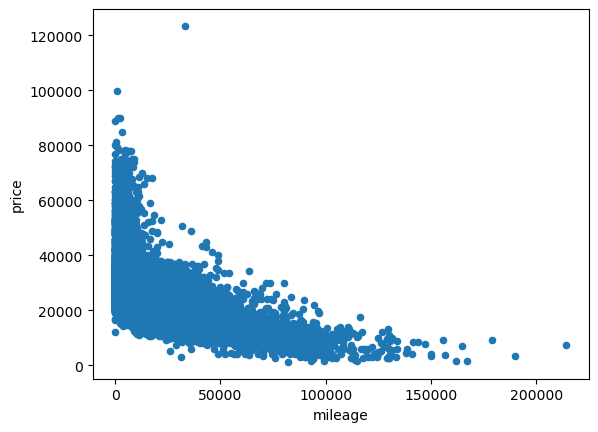

In [60]:
df.plot('mileage', 'price', kind='scatter')

На диаграмме рассеяния наблюдается обратная зависимость между ценой автомобиля и пробегом: в среднем чем выше цена машины, тем меньше её пробег. Большинство автомобилей с низкой ценой имеют большой разброс пробега, часто превышающий 100 000 км. Более дорогие автомобили, как правило, имеют значительно меньший пробег.

<Axes: xlabel='year', ylabel='price'>

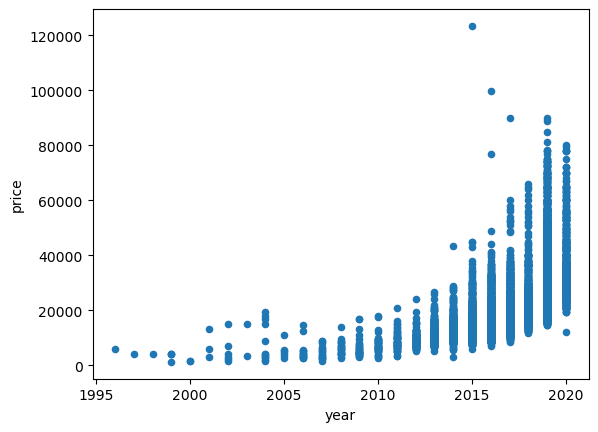

In [69]:
df.plot('year', 'price', kind='scatter')

Здесь тоже ничего удивительного: с увеличением возраста автомобиля его цена снижается. 

In [90]:
mean_prices = df.groupby('year')['price'].mean()

<Axes: xlabel='year'>

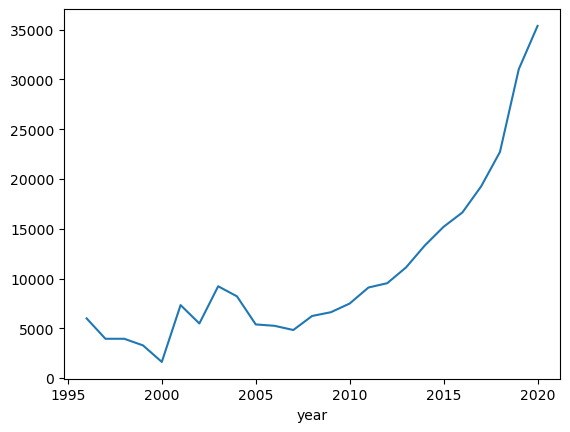

In [94]:
mean_prices.plot()

Можно заметить тренд: начиная с 1995 года цена на автомобили росла с небольшими просадками.

In [97]:
fuelType_mean_price = df.groupby('fuelType')['price'].mean()

<Axes: xlabel='fuelType'>

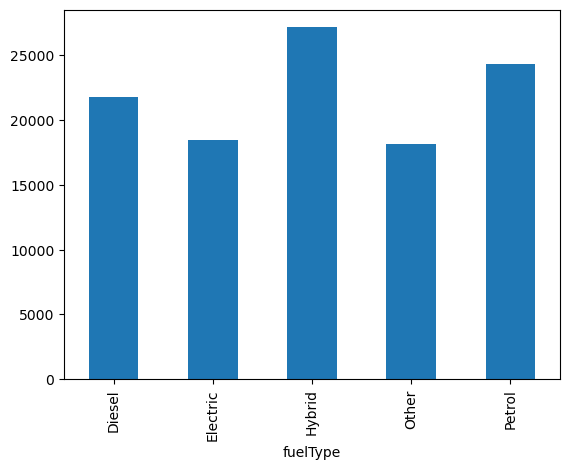

In [99]:
fuelType_mean_price.plot(kind='bar')

Самыми дорогими оказались автомобили-гибриды, а самыми дешёвыми - электрические (в среднем). 

<Axes: xlabel='model'>

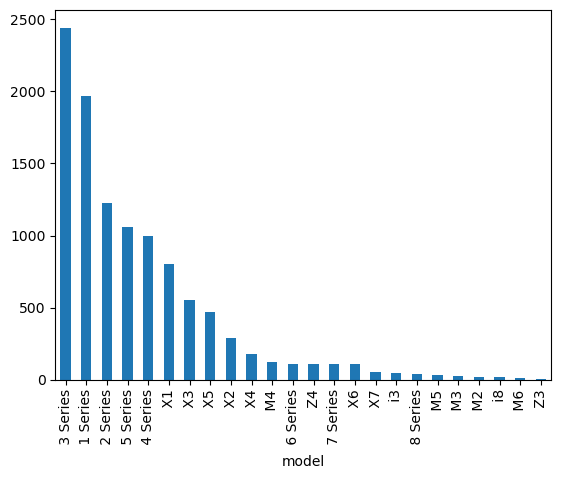

In [102]:
df['model'].value_counts().plot(kind='bar')

Больше всего машин 3Series и 1Series, они считаются одними из лучших по соотношению цена-качество и пользуются большим спросом. Z3 - кабриолет, который перестали выпускать в 2002 году, этих моделей меньше всего.